In [1]:
import sys
sys.path.append("..")

In [2]:
from src.config import CLASS_NAMES
from src.data_utils import validate_all_labels

In [3]:
validation_result = validate_all_labels()
validation_result

{'files_checked': 8099,
 'files_with_problems': 0,
 'empty_files': 0,
 'total_boxes': 75994,
 'class_counts': {0: 13802,
  1: 7730,
  2: 318,
  3: 8950,
  4: 134,
  5: 670,
  6: 759,
  7: 4647,
  8: 1945,
  9: 2790,
  10: 927,
  11: 15850,
  12: 11985,
  13: 157,
  14: 4560,
  15: 240,
  16: 530},
 'first_problems': []}

In [4]:
import pandas as pd
class_table = pd.DataFrame({
    "class_id": list(range(len(CLASS_NAMES))),
    "class_name": [CLASS_NAMES.get(i) for i in range(len(CLASS_NAMES))],
    "no_of_boxes": [validation_result["class_counts"].get(i,0) for i in range(len(CLASS_NAMES))]
})

class_table

,class_id,class_name,no_of_boxes
0,0,person,13802
1,1,ear,7730
2,2,ear-mufs,318
3,3,face,8950
4,4,face-guard,134
5,5,face-mask,670
6,6,foot,759
7,7,tool,4647
8,8,glasses,1945
9,9,gloves,2790


In [5]:
class_table.sort_values(by="no_of_boxes", ascending=False, inplace=True)

In [6]:
class_table

,class_id,class_name,no_of_boxes
11,11,hands,15850
0,0,person,13802
12,12,head,11985
3,3,face,8950
1,1,ear,7730
7,7,tool,4647
14,14,shoes,4560
9,9,gloves,2790
8,8,glasses,1945
10,10,helmet,927


In [7]:
from collections import Counter
from src.data_utils import read_label
from src.config import LABELS_DIR

image_count = Counter()

for path in LABELS_DIR.glob("*.txt"):
    labels = read_label(path)
    classes_in_image = {box["class_id"] for box in labels}
    for i in classes_in_image:
        image_count[i] += 1


In [8]:
class_table["no_of_images"] = class_table["class_id"].map(image_count)
class_table["boxes_per_image"] = class_table["no_of_boxes"] / class_table["no_of_images"].round(2)

In [9]:
class_table = class_table.sort_values(by="no_of_images", ascending=False).reset_index(drop=True)
print(class_table.to_string())

    class_id    class_name  no_of_boxes  no_of_images  boxes_per_image
0          0        person        13802          7617         1.811999
1         12          head        11985          6495         1.845266
2         11         hands        15850          6455         2.455461
3          3          face         8950          5646         1.585193
4          1           ear         7730          4884         1.582719
5          7          tool         4647          2257         2.058928
6          8       glasses         1945          1588         1.224811
7         14         shoes         4560          1570         2.904459
8          9        gloves         2790          1321         2.112036
9         10        helmet          927           466         1.989270
10         5     face-mask          670           395         1.696203
11         6          foot          759           347         2.187320
12         2      ear-mufs          318           223         1.426009
13    

In [10]:
class_table.to_csv("../docs/class_balance.csv", index=False)

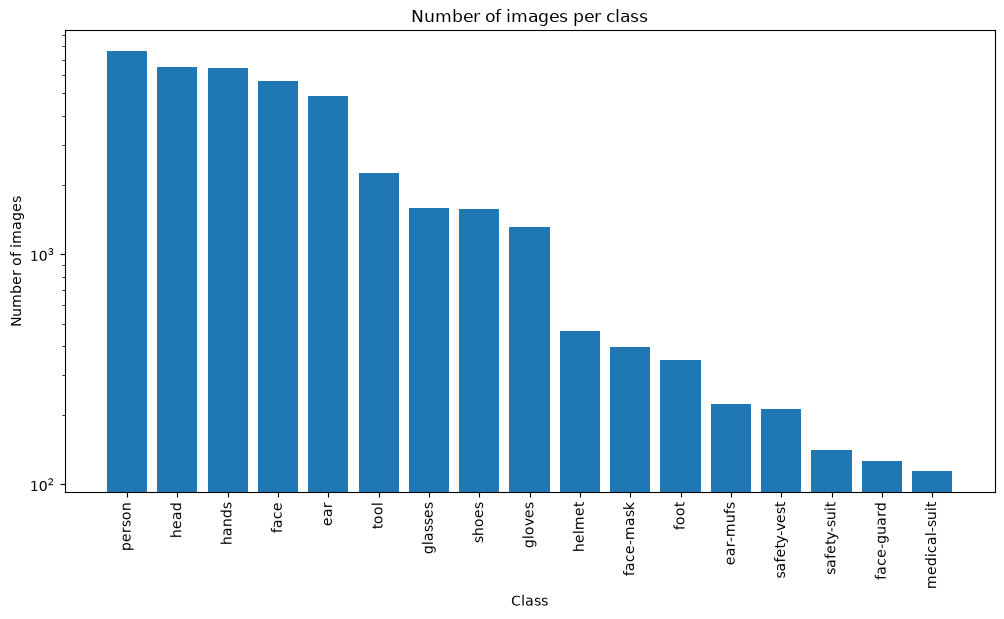

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(class_table["class_name"], class_table["no_of_images"], log=True)
plt.xticks(rotation=90)
plt.title("Number of images per class")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.savefig("../docs/class_balance.png")
plt.show()

# Box sizes

In [12]:
box_data = []

for label in LABELS_DIR.glob("*.txt"):
    labels = read_label(label)
    for box in labels:
        image_name = label.stem
        class_id = box["class_id"]
        class_name = CLASS_NAMES.get(box["class_id"])
        x,y,w,h = box["x_center"], box["y_center"], box["width"], box["height"]
        area = w * h
        box_data.append({
            "image_name": image_name,
            "class_id": class_id,
            "class_name": class_name,
            "x": x,
            "y": y,
            "w": w,
            "h": h,
            "area": area
        })

In [13]:
box_size_df = pd.DataFrame(box_data)

In [14]:
box_size_df["size_group"] = [
	"small" if area < 0.0025
	else "medium" if 0.0025 <= area < 0.0225
	else "large"
	for area in box_size_df["area"]
]

In [15]:
box_size_df["size_group"]

0         large
1        medium
2         large
3         large
4         large
          ...  
75989    medium
75990    medium
75991     large
75992     large
75993     large
Name: size_group, Length: 75994, dtype: str

In [16]:
small_percent = len(box_size_df[box_size_df["size_group"] == "small"]) / len(box_size_df)
small_percent

0.29707608495407534

In [17]:
medium_percent = len(box_size_df[box_size_df["size_group"] == "medium"]) / len(box_size_df)
large_percent = len(box_size_df[box_size_df["size_group"] == "large"]) / len(box_size_df)

In [18]:
medium_percent, large_percent

(0.36626575782298604, 0.3366581572229386)

In [19]:
small_percent + medium_percent + large_percent

1.0

In [20]:
order = ["small", "medium", "large"]

# Share of each class's boxes in each size group (rows add up to 100)
share = pd.crosstab(box_size_df["class_name"], box_size_df["size_group"],
                    normalize="index") * 100
share = share.reindex(columns=order, fill_value=0).round(1)

In [21]:
from src.config import DOCS_DIR, TRAIN_IMGSZ
import numpy as np

median_area = box_size_df.groupby("class_name")["area"].median()
share["median_area"] = median_area.round(5)
share["median_side_px"] = (np.sqrt(median_area) * TRAIN_IMGSZ).round(1)

In [22]:
share = share.sort_values("small", ascending=False)
print(share.to_string())
share.to_csv(DOCS_DIR / "box_sizes_by_class.csv")

size_group    small  medium  large  median_area  median_side_px
class_name                                                     
ear            84.6    15.3    0.1      0.00079            18.0
foot           62.2    36.4    1.4      0.00169            26.3
shoes          52.4    44.4    3.2      0.00229            30.7
helmet         49.8    33.8   16.4      0.00251            32.1
safety-vest    41.7    30.8   27.5      0.00524            46.3
gloves         39.4    39.4   21.2      0.00471            43.9
face-mask      36.3    46.6   17.2      0.00536            46.8
tool           29.6    32.9   37.5      0.01009            64.3
glasses        28.7    62.2    9.2      0.00525            46.4
hands          26.2    54.9   18.8      0.00666            52.2
head           19.0    36.1   44.9      0.01869            87.5
face           17.9    55.3   26.8      0.01109            67.4
ear-mufs       10.7    53.8   35.5      0.01418            76.2
safety-suit     9.2    31.2   59.6      

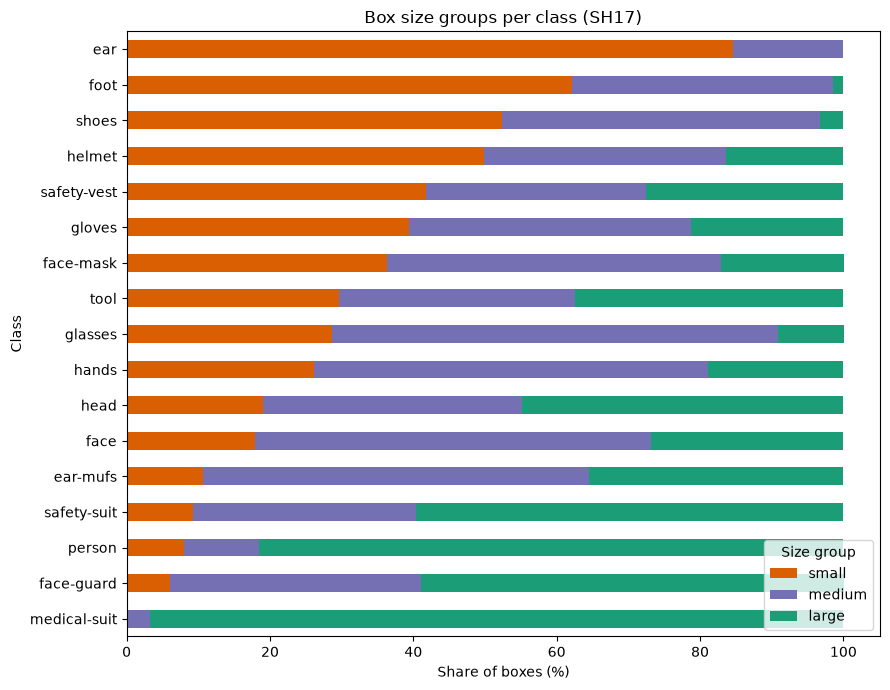

In [23]:
fig, ax = plt.subplots(figsize=(9, 7))
share[order].iloc[::-1].plot(kind="barh", stacked=True, ax=ax,
                             color=["#d95f02", "#7570b3", "#1b9e77"])
ax.set_xlabel("Share of boxes (%)")
ax.set_ylabel("Class")
ax.set_title("Box size groups per class (SH17)")
ax.legend(title="Size group", loc="lower right")
plt.tight_layout()
plt.savefig(DOCS_DIR / "box_sizes_by_class.png", dpi=150)
plt.show()

# Duplicates

In [24]:
from collections import defaultdict
from hashlib import md5
from tqdm import tqdm
from src.config import IMAGES_DIR, IMAGE_EXTS


def file_hash(path):
    """Return the MD5 fingerprint of a file's contents."""
    h = md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()


In [25]:
image_files = sorted(f for f in IMAGES_DIR.iterdir() if f.suffix.lower() in IMAGE_EXTS)

groups = defaultdict(list)  # fingerprint -> list of file names
for path in tqdm(image_files, desc="Hashing"):
    groups[file_hash(path)].append(path.name)

Hashing: 100%|██████████| 8099/8099 [00:09<00:00, 814.73it/s]


In [26]:
duplicate_groups = {h: names for h, names in groups.items() if len(names) > 1}
extra_files = sum(len(names) - 1 for names in duplicate_groups.values())

print("Images hashed:", len(image_files))
print("Duplicate groups:", len(duplicate_groups))
print("Extra files (copies beyond the first):", extra_files)

Images hashed: 8099
Duplicate groups: 0
Extra files (copies beyond the first): 0


In [33]:
from src.config import RAW_DIR
import json

meta_data_folder = RAW_DIR / "meta-data"

data_file = [f for f in meta_data_folder.glob("*.json")]
len(data_file)


8099

In [37]:
with open(data_file[0], "r", encoding="utf-8") as f:
    meta = json.load(f)

meta

{'id': 2469,
 'width': 5760,
 'height': 3840,
 'url': 'https://www.pexels.com/photo/cement-flowing-at-construction-site-2469/',
 'photographer': 'Life Of Pix',
 'photographer_url': 'https://www.pexels.com/@life-of-pix',
 'photographer_id': 2660,
 'avg_color': '#867973',
 'src': {'original': 'https://images.pexels.com/photos/2469/building-construction-building-site-constructing.jpg',
  'large2x': 'https://images.pexels.com/photos/2469/building-construction-building-site-constructing.jpg?auto=compress&cs=tinysrgb&dpr=2&h=650&w=940',
  'large': 'https://images.pexels.com/photos/2469/building-construction-building-site-constructing.jpg?auto=compress&cs=tinysrgb&h=650&w=940',
  'medium': 'https://images.pexels.com/photos/2469/building-construction-building-site-constructing.jpg?auto=compress&cs=tinysrgb&h=350',
  'small': 'https://images.pexels.com/photos/2469/building-construction-building-site-constructing.jpg?auto=compress&cs=tinysrgb&h=130',
  'portrait': 'https://images.pexels.com/phot

In [52]:
existing_file = []
rows = []
image_stem = {f.stem for f in IMAGES_DIR.iterdir() if f.suffix.lower() in IMAGE_EXTS}

for data in data_file:
    with open(data, "rb") as f:
        meta_stem = data.stem
        meta = json.load(f)
        if meta_stem in image_stem:
            existing_file.append(meta_stem)
        rows.append({
            "stem": meta_stem,
            "photographer_id": meta["photographer_id"],
            "photographer_name": meta["photographer"]
        })

print(len(existing_file))


8099


In [53]:
len(rows)

8099

In [54]:
photo_df = pd.DataFrame(rows)
photo_df.head()

,stem,photographer_id,photographer_name
0,building-construction-building-site-constructing,2660,Life Of Pix
1,career-firefighter-relaxing-job-162540,2659,Pixabay
2,carrying-head-indian-farm-worker-158011,2659,Pixabay
3,construction-site-build-construction-work-159306,2659,Pixabay
4,construction-site-build-construction-work-159358,2659,Pixabay


In [56]:
photo_df["stem"].duplicated().sum()

np.int64(0)

In [62]:
photo_df["photographer_id"].groupby(photo_df["photographer_name"]).value_counts().sort_values(ascending=False)

photographer_name          photographer_id
cottonbro studio           1437723            787
Anna Shvets                1984515            357
Ono  Kosuki                3651207            284
Andrea Piacquadio          224453             278
Ketut Subiyanto            2515433            245
                                             ... 
Önder  Ceneviz             753062295            1
Abhishek Saini             1415858              1
Abdulla Hafeez             124357828            1
Abdul Zreika               233770               1
Abdiel Hernandez Villegas  297997938            1
Name: count, Length: 922, dtype: int64

In [64]:
photo_df.to_csv(DOCS_DIR / "image_photographer.csv", index=False)